# Testing different acquisition with direct reconstruction

In [1]:
# Import
import shutil
import torch
import tempfile
from pathlib import Path
from mrpro.data import KData  # Import the KData class
from mrpro.data.traj_calculators import KTrajectoryPulseq
from mrpro.data._SpatialDimension import SpatialDimension

import requests

# Local path
# US 93
h5_path1 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00095_FID06179_cartesian_2d_final_poiss_0_3_us_93_20240704_162827.h5'
seq_path1 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.3_us_93_20240704_162827.seq'
# US 256
h5_path2 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00097_FID06181_cartesian_2d_final_poiss_0_us_256_20240704_162847.h5'
seq_path2 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0_us_256_20240704_162847.seq'
# US 26
h5_path3 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00093_FID06177_cartesian_2d_final_poiss_0_01_us_26_20240704_162837.h5'
seq_path3 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.01_us_26_20240704_162837.seq'
# US 46
h5_path4 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00094_FID06178_cartesian_2d_final_poiss_0_1_us_46_20240704_162906.h5'
seq_path4 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.1_us_46_20240704_162906.seq'
# US 141
h5_path5 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/meas_MID00096_FID06180_cartesian_2d_final_poiss_0_5_us_141_20240704_162804.h5'
seq_path5 = '/data/bouill01/PTBSequences/PTBSequences/seqfiles/final/cartesian_2d_final_poiss_0.5_us_141_20240704_162804.seq'


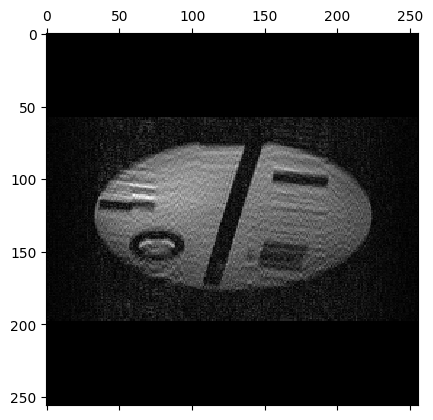

In [2]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path5, KTrajectoryPulseq(seq_path=seq_path5))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

In [31]:
kdatapuls.data.shape

torch.Size([1, 4, 1, 140, 256])

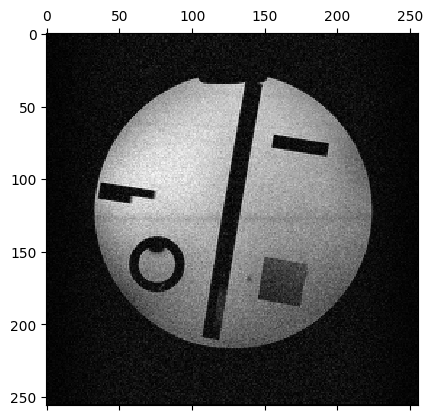

In [32]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path2, KTrajectoryPulseq(seq_path=seq_path2))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

In [34]:
kdatapuls.data.shape

torch.Size([1, 4, 1, 255, 256])

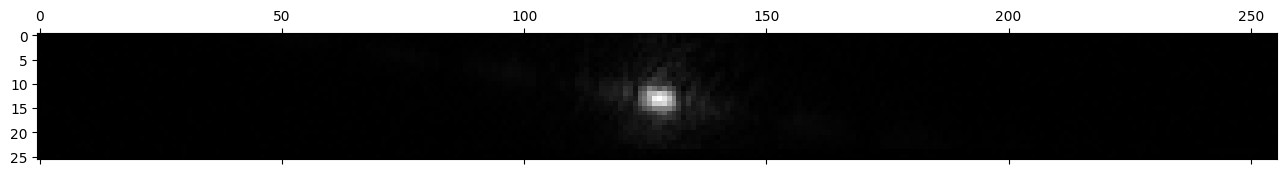

In [6]:
import mrpro

# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path3, KTrajectoryPulseq(seq_path=seq_path3))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

# Calculate dcf using the trajectory
dcf_operator = mrpro.data.DcfData.from_traj_voronoi(kdatapuls.traj).as_operator()
# Define Fourier operator
cart_operator = mrpro.operators.CartesianSamplingOp(
    encoding_matrix=kdatapuls.header.encoding_matrix,
    traj=kdatapuls.traj,
)
adjoint_operator = cart_operator.H

img_coilwise = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)
csm_operator = mrpro.data.CsmData.from_idata_walsh(img_coilwise).as_operator()

# Perform Direct Reconstruction
forward_operator = cart_operator @ csm_operator
adjoint_operator = cart_operator.H
img = mrpro.data.IData.from_tensor_and_kheader(*adjoint_operator(kdatapuls.data), kdatapuls.header)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

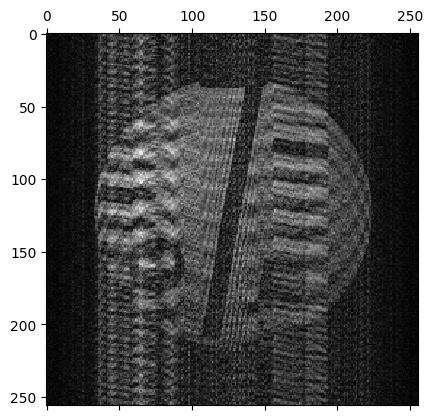

In [ ]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path4, KTrajectoryPulseq(seq_path=seq_path4))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')

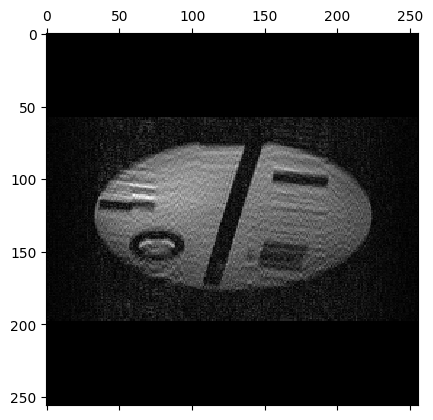

In [ ]:
import mrpro
from mrpro.data.traj_calculators import KTrajectoryIsmrmrd

# Use the trajectory that is stored in the ISMRMRD file
# trajectory = mrpro.data.traj_calculators.KTrajectoryIsmrmrd(seq_file)
# Load in the Data from the ISMRMRD file
kdatapuls = KData.from_file(h5_path5, KTrajectoryPulseq(seq_path=seq_path5))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on gpu: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

import matplotlib.pyplot as plt

# Display the reconstructed image
# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  #  images, z, y, x
plt.matshow(first_img, cmap='gray')